# Correlations Go to One 🔗
### "In a crisis, everything falls together." Partly true — and partly a trick of the ruler.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

**Beat 0 · Verdict (real tape).** When markets get stormy, these 20 big US stocks really do start
moving together: their average correlation climbs from **0.21** in calm markets to
**0.47** in turbulent ones, and almost none of that is the statistical illusion
that usually inflates this number. But it never goes anywhere near one, and diversification
shrinks rather than fails. Numbers from [`docs/results.md`](../docs/results.md), as-of
2022-11-30.

> 📓 **This is the plain-language layer.** The artefact benchmark, the bootstrap and the
> Forbes–Rigobon algebra are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is computed by the code beside it, on the
> pinned real tape.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 80
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from goestoone import data, strategy as st
R, m = data.load_returns()
print(f"as-of {data.AS_OF} | {R.shape[1]} stocks (survivor sample), {len(R)} days, "
      f"{R.index[0].date()} -> {R.index[-1].date()}")
print(f"fingerprints: stocks {data.fingerprint(data.load_prices())}, "
      f"index {data.fingerprint(data.load_index())}")

as-of 2022-11-30 | 20 stocks (survivor sample), 8293 days, 1990-01-03 -> 2022-11-30
fingerprints: stocks bbc82157e299, index e223c581ae22


## 1 · The claim

*"In a crisis all correlations go to one — diversification fails exactly when you need it."*
It's one of the most repeated lines in finance, and practitioners have real scars behind it: in
2008 and again in March 2020, assets that were supposed to zig while others zagged fell
together. Sébastien Page and Robert Panariello put the strong version in a 2018 *Financial
Analysts Journal* article titled, simply, **"When Diversification Fails"**.

The strongest version of the claim has three parts: (a) correlations rise sharply in crises,
(b) that rise is real, not a measurement quirk, and (c) it is big enough to wreck the benefit of
holding many stocks.

## 2 · So what?

If it were fully true, "diversify" would be a fair-weather promise: the protection would vanish
exactly in the months that decide a portfolio's fate, and holding 20 stocks would be no safer
than holding one when it mattered. If it were *false*, risk models could keep using calm-period
correlations and only worry about volatility.

The truth decides how much a sensible investor should over-estimate risk "just in case".

## 3 · How we'd know

There's a catch that most retellings miss. **If you pick the stormy days, you will measure a
higher correlation even if nothing about the relationship changed.** Big common moves are what
*make* a day stormy, and big common moves are what correlation counts. So we:

1. measure the naive number six different ways (four use only *yesterday's* information to say
   "this is a crisis day");
2. build a fake market where the correlation is **constant by construction** but volatility
   swings exactly like the real one — and run the identical measurement on it. Whatever it
   reports is pure illusion;
3. call the difference "genuine" and put an error bar on it;
4. ask what the genuine part does to someone who simply holds all 20 stocks.

**What would make it a mirage:** a genuine increase indistinguishable from zero, or a portfolio
whose crisis risk is fully explained by volatility alone.

## 4 · The teardown

### 4.1 How correlated are these stocks, over time?

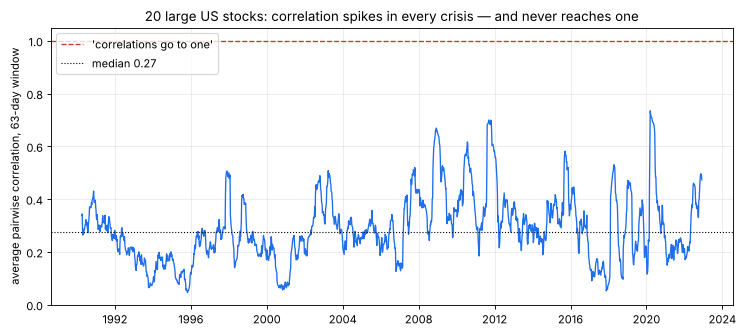

highest 63-day reading: 0.73 (window ending 2020-03-13)


In [2]:
roll = st.rolling_avg_corr(R, window=63, step=5)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(roll.index, roll, color="#1f6feb", lw=1.2)
ax.axhline(1.0, color="#c0392b", ls="--", lw=1.2, label="'correlations go to one'")
ax.axhline(roll.median(), color="k", ls=":", lw=1, label=f"median {roll.median():.2f}")
ax.set_ylim(0, 1.05); ax.set_ylabel("average pairwise correlation, 63-day window")
ax.set_title("20 large US stocks: correlation spikes in every crisis — and never reaches one")
ax.legend(loc="upper left")
plt.show()
print(f"highest 63-day reading: {roll.max():.2f} (window ending {roll.idxmax().date()})")

Every spike lines up with a crisis — 1998, 2002, 2008, 2011, 2020. The spikes are real. The
red line at one is never threatened.

### 4.2 The naive table

In [3]:
labels = st.all_labels(m)
rows = []
for k, lab in labels.items():
    rc = st.regime_corr(R, lab)
    rows.append({"how 'crisis' is defined": st.REGIMES[k]["label"],
                 "uses only the past?": "yes" if st.REGIMES[k]["past_only"] else "NO",
                 "calm": rc["calm"], "crisis": rc["crisis"], "gap": rc["diff"]})
naive = pd.DataFrame(rows)
naive

,how 'crisis' is defined,uses only the past?,calm,crisis,gap
0,Past 21-day S&P vol: top decile vs bottom half,yes,0.206,0.466,0.260
1,Past 63-day S&P vol: top decile vs bottom half,yes,0.213,0.458,0.245
2,"GARCH(1,1) one-step vol forecast: top decile v...",yes,0.196,0.474,0.278
3,S&P drawdown at t-1 worse than -20% vs better ...,yes,0.208,0.436,0.228
4,Month's own realised vol: top-decile months vs...,NO,0.171,0.491,0.320
5,Day's own S&P return in bottom 5% vs abs. retu...,NO,0.045,0.247,0.202


### 4.3 The illusion, measured

Now the fake market: every stock keeps its own real volatility pattern, but the correlation
between their surprises is held **constant**. Run the same six measurements on it.

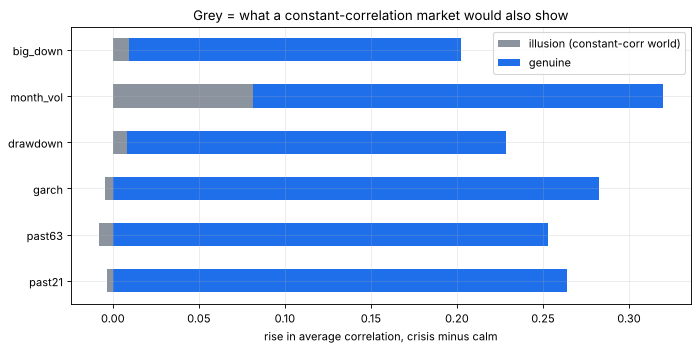

,real gap,illusion (constant-corr world),genuine
past21,0.260,-0.004,0.264
past63,0.245,-0.008,0.253
garch,0.278,-0.005,0.283
drawdown,0.228,0.008,0.220
month_vol,0.320,0.081,0.238
big_down,0.202,0.009,0.193


In [4]:
fit = st.fit_ccc_garch(R, m)
art = st.artefact_benchmark(fit, n_sims=6, exceed=False)
tbl = pd.DataFrame({
    "real gap": [st.regime_corr(R, labels[k])["diff"] for k in labels],
    "illusion (constant-corr world)": [art["regimes"][k]["diff_mean"] for k in labels],
}, index=list(labels))
tbl["genuine"] = tbl["real gap"] - tbl["illusion (constant-corr world)"]
ax = tbl[["illusion (constant-corr world)", "genuine"]].plot.barh(
    stacked=True, color=["#8b949e", "#1f6feb"], figsize=(10, 4.5))
ax.set_xlabel("rise in average correlation, crisis minus calm")
ax.set_title("Grey = what a constant-correlation market would also show")
plt.show()
tbl

The grey slivers are the illusion. When "crisis" is defined from *yesterday's* information it is
essentially zero; when it is defined from the month's own turbulence — the way the folklore
usually measures — it is about a quarter of the gap. Either way the blue part, the genuine rise,
is large: **+0.26** on the headline definition, with an error bar of
[+0.15, +0.34].

> 🔬 **For the quants.** 40 constant-correlation GARCH paths in the pinned run (6 here),
> circular block bootstrap with 63-day blocks, labels carried with the days. See notebook 02 §3.

### 4.4 Does it hurt someone holding all 20?

Take an equal-weight book. Ask: in crisis periods, how risky *was* it, versus how risky it
*would have been* if each stock's volatility had jumped but correlations had stayed at their calm
level?

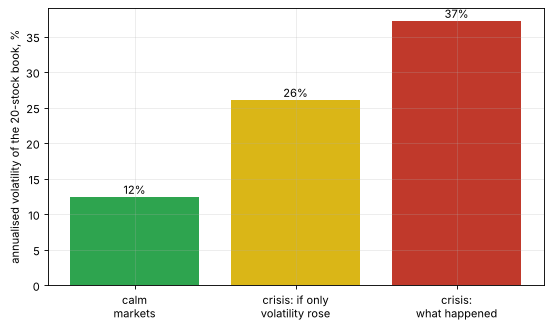

correlation shortfall: +43%   diversification ratio 2.14 calm -> 1.44 crisis (1.00 = no diversification at all)


In [5]:
ps = st.portfolio_stats(R, labels["past21"])
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(["calm\nmarkets", "crisis: if only\nvolatility rose", "crisis:\nwhat happened"],
              [ps["vol_calm"] * 100, ps["vol_pred"] * 100, ps["vol_crisis"] * 100],
              color=["#2ea44f", "#dab617", "#c0392b"])
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5, f"{b.get_height():.0f}%",
            ha="center")
ax.set_ylabel("annualised volatility of the 20-stock book, %")
plt.show()
print(f"correlation shortfall: {ps['shortfall']:+.0%}   "
      f"diversification ratio {ps['dr_calm']:.2f} calm -> {ps['dr_crisis']:.2f} crisis "
      f"(1.00 = no diversification at all)")

The jump from yellow to red is the price of correlation rising. It is real and large. But the
diversification ratio — how much risk the mix removes compared to the average stock — falls
from about 2.1 to about 1.4, not to 1.0. **Diversification shrinks; it does not fail.**

In [6]:
ep = st.episode_table(R)
ep[["days", "corr_before", "corr_during", "ratio", "dr_before", "dr_during"]]

,days,corr_before,corr_during,ratio,dr_before,dr_during
episode,,,,,,
1998 LTCM / Russia,53,0.319,0.413,1.142,1.794,1.530
2001 September 11,33,0.122,0.258,1.364,2.358,1.707
2002 bear-market low,87,0.236,0.446,1.255,1.861,1.487
2008-09 Lehman / GFC,137,0.342,0.604,1.269,1.657,1.287
2010 flash crash / euro,63,0.327,0.604,1.318,1.664,1.251
2011 US downgrade,65,0.369,0.693,1.307,1.593,1.201
2015 China devaluation,32,0.341,0.664,1.354,1.731,1.252
2018 Q4 sell-off,63,0.308,0.456,1.176,1.767,1.499
2020 COVID crash,50,0.246,0.701,1.553,1.888,1.195


Each named crisis, with the yardstick a holder could actually have had: correlations from the
year *before*. Every row's `ratio` is above 1 — the book was riskier than "old correlations, new
volatilities" predicted — and every `dr_during` stays above 1.

## 5 · The verdict

**Signal: Real.** The crisis rise in correlation is genuine:
0.21 → 0.47, essentially none of it the statistical illusion when
crises are defined from past data, positive under all six definitions. Correlations do **not**
go to one — the highest 63-day reading in 33 years was 0.73.

**Tradability: Fragile.** A diversified stock book was about 43% riskier in
crises than volatility alone predicts, and its diversification ratio fell from 2.14
to 1.44. That matters for risk budgets; it is not a trade, so it can't be
"investable" — and it is not the collapse the slogan promises.

> 🔬 **For the quants.** A twist: by the Forbes–Rigobon yardstick there is *no contagion*
> at all — the whole rise is a louder market factor. That doesn't make it fake; it makes it
> undiversifiable. Notebook 02 §4.

## 6 · Could you trade it?

Not directly — there is no signal here that tells you what to buy. What you *can* do:

- **Stress the correlations, not just the volatilities.** Here the book's real crisis risk came
  out about 40% above what a model scaling calm covariances by crisis volatilities predicted.
- **Don't expect more stocks to fix it.** The rise is in the common factor; adding names from the
  same market adds the same factor.
- **Diversify across things that don't share that factor** (bonds, cash, explicit hedges) — and
  test *those* correlations in crises too. That's a different study.

## 7 · Going further 🚪

- Run the same machinery on **cross-asset** pairs (stocks vs Treasuries) where the sign of the
  correlation itself flips — the real "diversification failure" story may live there.
- Replace the Gaussian constant-correlation benchmark with **fat-tailed** shocks and see how much
  the contemporaneous illusion grows.
- The survivor panel is a known limit: a point-in-time constituent list would let a contributor
  check the reasoning about its direction.
- Neighbours: [578](../../578-cross-asset-correlation-regime/) asks whether high correlation
  *predicts* returns (it doesn't, the way people think);
  [974](../../974-diversification-saturation/) prices the *k*-th asset in calm averages.